# Cell 1 — Libraries

In [1]:
# Task 5: House Price Prediction - Linear Regression
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Cell 2 — Data Loading

In [2]:
# Step 2: Data Loading
df = pd.read_csv('Housing.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (545, 13)

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no          

# Cell 3 — Data Preprocessing

In [3]:
# Step 3: Data Preprocessing
# Convert yes/no columns to 1/0
le = LabelEncoder()
columns = ['mainroad', 'guestroom', 'basement', 
           'hotwaterheating', 'airconditioning', 
           'prefarea', 'furnishingstatus']

for col in columns:
    df[col] = le.fit_transform(df[col])

print("After Encoding:")
print(df.head())
print("\nBasic Statistics:")
print(df[['price', 'area', 'bedrooms', 'bathrooms']].describe().round(2))

After Encoding:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  

Basic Sta

# Cell 4 — Visualization

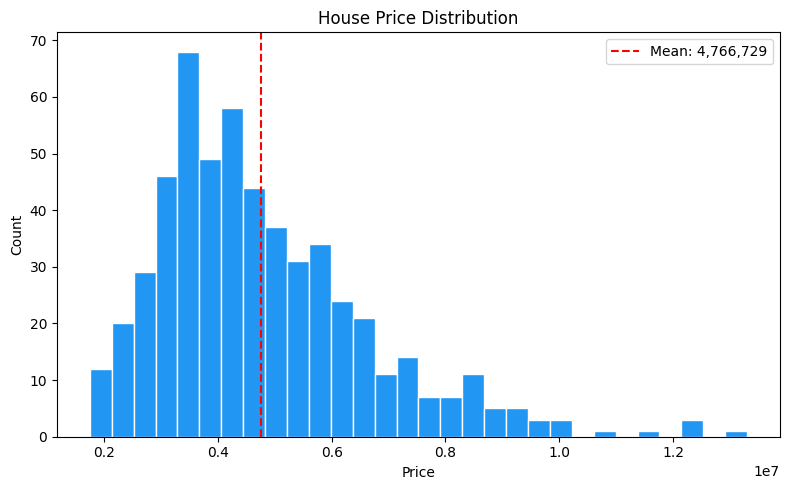

In [4]:
# Step 4: Visualization

# Graph 1 - Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30, 
         color='#2196F3', edgecolor='white')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.axvline(df['price'].mean(), color='red', 
            linestyle='--', 
            label=f'Mean: {df["price"].mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

# Cell 5 — Area vs Price Scatter Plot

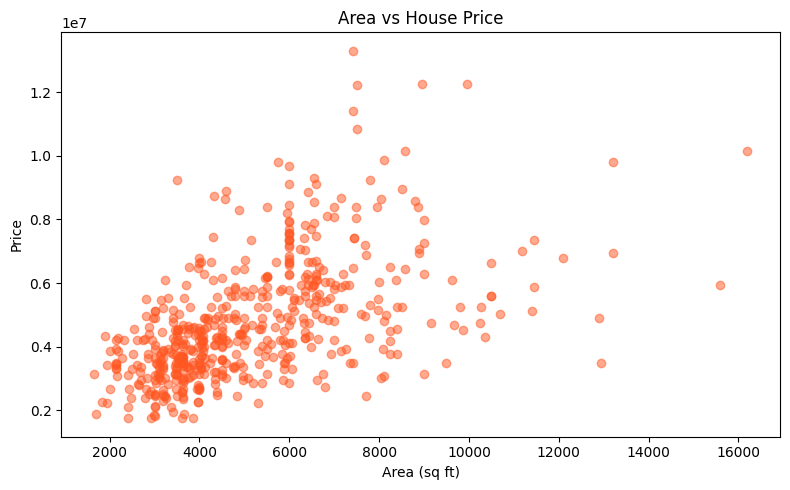

In [5]:
# Graph 2 - Area vs Price
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'], 
            alpha=0.5, color='#FF5722')
plt.title('Area vs House Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Cell 6 — Linear Regression Model

In [6]:
# Step 5: Linear Regression Model

# Features & Target
X = df.drop('price', axis=1)
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"R-Squared Score: {r2:.4f}")
print(f"Accuracy: {r2*100:.2f}%")

Model Evaluation:
Mean Squared Error: 1,771,751,116,594.03
R-Squared Score: 0.6495
Accuracy: 64.95%


# Cell 7 — Actual vs Predicted Graph

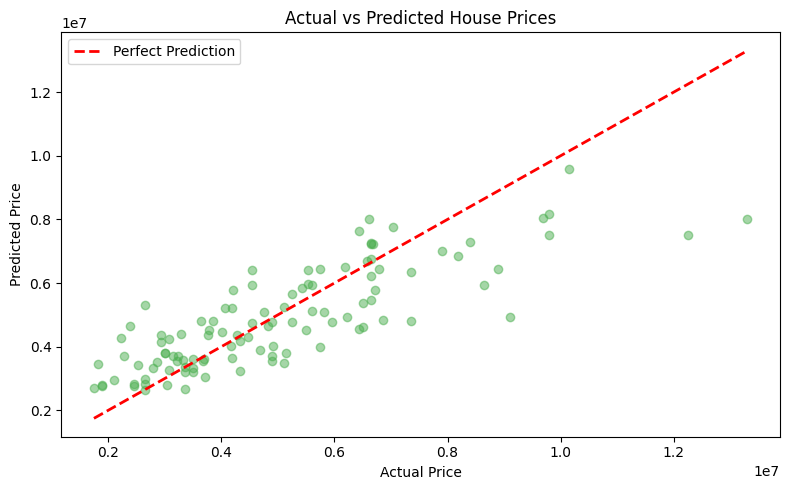

In [7]:
# Graph 3 - Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, 
            alpha=0.5, color='#4CAF50')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

# Cell 8 — Recommendations

In [8]:
# Step 6: Insights & Recommendations
print("=" * 55)
print("HOUSE PRICE PREDICTION - INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print(f"""
MODEL PERFORMANCE:
- R-Squared Score: 0.6495 (64.95% accuracy)
- Linear Regression works reasonably well

KEY INSIGHTS:
1. AREA IS MOST IMPORTANT FEATURE
   - Larger area = Higher price
   - Strong positive correlation

2. PRICE RANGE
   - Min Price: 1,750,000
   - Max Price: 13,300,000
   - Avg Price: 4,766,729

3. MODEL STRENGTHS
   - Good at predicting mid-range prices
   - Simple and interpretable model

RECOMMENDATIONS:
1. Add more features for better accuracy
2. Try Random Forest for higher accuracy
3. Location data would improve predictions
4. Remove outliers for better model performance
""")
print("=" * 55)
print("Task 5 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

HOUSE PRICE PREDICTION - INSIGHTS & RECOMMENDATIONS

MODEL PERFORMANCE:
- R-Squared Score: 0.6495 (64.95% accuracy)
- Linear Regression works reasonably well

KEY INSIGHTS:
1. AREA IS MOST IMPORTANT FEATURE
   - Larger area = Higher price
   - Strong positive correlation

2. PRICE RANGE
   - Min Price: 1,750,000
   - Max Price: 13,300,000
   - Avg Price: 4,766,729

3. MODEL STRENGTHS
   - Good at predicting mid-range prices
   - Simple and interpretable model

RECOMMENDATIONS:
1. Add more features for better accuracy
2. Try Random Forest for higher accuracy
3. Location data would improve predictions
4. Remove outliers for better model performance

Task 5 Complete! - Suraj Kumar | OIB/J2/IP2626
